# RQ1 — The directional reframe (final analysis)

This notebook follows
[rq1_consolidated_analysis.ipynb](rq1_consolidated_analysis.ipynb) and
[rq1_max_single_resolution.ipynb](rq1_max_single_resolution.ipynb). It locks
down the RQ1 result by **promoting the directional outcome
(`supp_mean_signed = ½·((δ_a_joint − δ_a_single) + (δ_b_joint − δ_b_single))`)
from a probe to the primary RQ1 metric** and running the full nested-OLS battery
on it. Coherence filter kept throughout (`coh_steered ≥ 30`).

## Why this reframe

The magnitude outcome `mean_joint_abs` was beaten by single-trait amplitude:
once `max_single_abs` enters the controls, β_cos collapses from +0.285 to
+0.051 (Probe 1 showed this is NOT a multicollinearity artefact — pooled
r(cos, max_single) = +0.10, VIF = 2.5). We concede the magnitude point:

> **The magnitude of joint expression is primarily an amplitude property** —
> behaviours that steer strongly alone steer strongly together. Geometry adds
> little to magnitude on its own merits.

The geometric question was never really about magnitude though. The
hypothesis from the literature (Young 2026 alignment-tax angle-frontier; the
partial-correlation argument) is that *angle governs the trade-off*: do
behaviours **reinforce or suppress** under joint injection? That's a sign
question, not a magnitude question.

**The single-trait amplitude defence has no purchase on direction.** A
magnitude (`max_single_abs`) can predict how big joint expression is. It
cannot — by construction — predict whether joint expression is *larger or
smaller* than the single-trait baseline. Only the geometric interaction
between the two vectors can do that.

So the proper RQ1 metric is the *signed change from single to joint*:

- `supp_signed_a = δ_a_joint − δ_a_single`
- `supp_signed_b = δ_b_joint − δ_b_single`
- `supp_mean_signed = ½·(supp_signed_a + supp_signed_b)` — primary
- `supp_min_signed = min(supp_signed_a, supp_signed_b)` — robustness on the
  more-suppressed trait

These are *additive* differences, not ratios, so they don't blow up when
`δ_single ≈ 0` (the reason we demoted ratio-based `supp_mean` earlier).

## Identifiability note

`mechanical_push` is a deterministic function of `cos` within a single
scheme (the closed-form per-axis push). Per-scheme VIFs were Inf / 125 in
`rq1_max_single_resolution`. So any model containing both `cos` and
`mechanical_push` is only trustworthy **pooled** (where scheme dummies
absorb the functional difference). Per-scheme β_cos numbers are reported only
as directional/sign corroboration with this caveat in mind.

In [1]:
# Imports + paths + rng + utilities (re-using the by-hand OLS approach)
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

REPO = Path.cwd().parents[1]
RNG  = np.random.default_rng(0)

CSV_PATH = REPO / "analysis/rq1_consolidated/consolidated_coh30.csv"
df = pd.read_csv(CSV_PATH)
print(f"Loaded {CSV_PATH}  rows={len(df)}  schemes={dict(df['scheme'].value_counts())}")

# Sem_sim is in the CSV (filled in the consolidated notebook); confirm presence
assert "sem_sim" in df.columns, "sem_sim missing — rebuild consolidated first"
print(f"NaN sem_sim rows: {df['sem_sim'].isna().sum()}")

Loaded /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition/analysis/rq1_consolidated/consolidated_coh30.csv  rows=76  schemes={'normTrue': 28, 'normFalse': 26, 'per_axis': 22}
NaN sem_sim rows: 0


In [2]:
# Recompute directional metrics here so the notebook is self-contained
df["supp_signed_a"]   = df["delta_a_joint"] - df["delta_a_single"]
df["supp_signed_b"]   = df["delta_b_joint"] - df["delta_b_single"]
df["supp_mean_signed"] = 0.5 * (df["supp_signed_a"] + df["supp_signed_b"])
df["supp_min_signed"]  = np.minimum(df["supp_signed_a"], df["supp_signed_b"])
print("Directional metrics built. Quick stats:\n")
print(df[["supp_signed_a","supp_signed_b","supp_mean_signed","supp_min_signed"]].describe().round(2))

Directional metrics built. Quick stats:

       supp_signed_a  supp_signed_b  supp_mean_signed  supp_min_signed
count          76.00          76.00             76.00            76.00
mean           -3.25          -9.68             -6.47           -20.69
std            23.29          24.80             16.26            22.08
min           -57.92         -72.56            -39.96           -72.56
25%           -14.62         -26.63            -16.01           -37.30
50%            -3.82          -4.69             -6.13           -18.93
75%            13.00           6.97              4.35            -5.16
max            46.24          33.06             37.10            32.91


In [3]:
# OLS utilities (matching the previous two notebooks)
def fit_ols(X, y):
    X = np.asarray(X, float); y = np.asarray(y, float)
    n, k = X.shape
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    rss = float(resid @ resid)
    dof = n - k
    sigma2 = rss / dof if dof > 0 else np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    tss = float(((y - y.mean())**2).sum())
    r2 = 1 - rss / tss if tss > 0 else np.nan
    return {"beta": beta, "se": se, "rss": rss, "n": n, "k": k,
            "dof": dof, "r2": r2, "resid": resid}


def nested_F(fit_red, fit_full):
    rss_r, rss_f = fit_red["rss"], fit_full["rss"]
    p_diff = fit_full["k"] - fit_red["k"]
    df_f = fit_full["dof"]
    if p_diff <= 0 or df_f <= 0: return np.nan, np.nan
    F = ((rss_r - rss_f) / p_diff) / (rss_f / df_f)
    return F, 1 - stats.f.cdf(F, p_diff, df_f)


def pooled_design(sub, cols_continuous):
    Z_cont = (StandardScaler().fit_transform(sub[cols_continuous].values)
              if cols_continuous else np.empty((len(sub), 0)))
    d_nT = (sub["scheme"] == "normTrue").astype(float).values
    d_pa = (sub["scheme"] == "per_axis").astype(float).values
    X = np.column_stack([np.ones(len(sub)), Z_cont, d_nT, d_pa])
    names = ["(intercept)"] + list(cols_continuous) + ["d_normTrue", "d_per_axis"]
    return X, names


def fit_pooled(sub, cols_continuous, y_col):
    X, names = pooled_design(sub, cols_continuous)
    y = StandardScaler().fit_transform(sub[[y_col]].values).ravel()
    fit = fit_ols(X, y); fit["cols"] = names
    return fit


def beta_of(fit, name):
    i = fit["cols"].index(name)
    return fit["beta"][i], fit["se"][i]


def partial_r(y, x, controls):
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c) for c in controls])
    bx, *_ = np.linalg.lstsq(X, x, rcond=None)
    by, *_ = np.linalg.lstsq(X, y, rcond=None)
    return stats.pearsonr(x - X @ bx, y - X @ by)


def vif(target_col, other_cols, frame):
    X = StandardScaler().fit_transform(frame[other_cols].values)
    y = StandardScaler().fit_transform(frame[[target_col]].values).ravel()
    X = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    rss = float(resid @ resid); tss = float(((y - y.mean())**2).sum())
    r2 = 1 - rss / tss
    return 1.0 / (1.0 - r2) if r2 < 1 else np.inf

print("Utilities loaded.")

Utilities loaded.


## Part 0 — The raw directional fact, honestly

Before any regression, the headline descriptive question: do antipodal pairs
suppress and aligned pairs reinforce?

The data forces an honest framing. The naive sign rule
"cos < 0 → suppression, cos > 0 → reinforcement" gets **48.7% pooled match
on this frame — worse than coin flip.** The reason: *most* pairs suppress
overall, even the aligned ones. The injection split (joint dose is divided
between two directions) is a magnitude tax that almost everyone pays. So the
real RQ1 prediction isn't a strict sign rule; it's a *continuous shift*:

> More positive cos → less suppression.

Three ways to see this:

In [4]:
# 0a. Pooled contingency: cos sign × supp sign
df["cos_sign"]  = np.sign(df["cos"]).astype(int)
df["supp_sign"] = np.sign(df["supp_mean_signed"]).astype(int)

print("=== Pooled contingency  cos sign × supp_mean_signed sign ===")
print(pd.crosstab(df["cos_sign"], df["supp_sign"], margins=True))
print()

# Fisher exact on 2x2 (cos<0 vs cos>=0) × (supp<0 vs supp>=0)
tab = np.array([
    [((df["cos"] <  0) & (df["supp_mean_signed"] <  0)).sum(),
     ((df["cos"] <  0) & (df["supp_mean_signed"] >= 0)).sum()],
    [((df["cos"] >= 0) & (df["supp_mean_signed"] <  0)).sum(),
     ((df["cos"] >= 0) & (df["supp_mean_signed"] >= 0)).sum()],
])
print("2×2 (rows: cos<0 / cos≥0, cols: supp<0 / supp≥0)")
print(tab)
odds, p_fisher = stats.fisher_exact(tab, alternative="two-sided")
print(f"  Fisher exact (two-sided): odds ratio = {odds:.3f}, p = {p_fisher:.4f}")
n_anti = tab[0].sum(); n_aligned = tab[1].sum()
print(f"  Conditional suppression rate:")
print(f"    cos < 0   pairs: {tab[0,0]}/{n_anti} = {100*tab[0,0]/n_anti:.0f}% suppress")
print(f"    cos ≥ 0   pairs: {tab[1,0]}/{n_aligned} = {100*tab[1,0]/n_aligned:.0f}% suppress")

=== Pooled contingency  cos sign × supp_mean_signed sign ===
supp_sign  -1   1  All
cos_sign              
-1         14   3   17
1          36  23   59
All        50  26   76

2×2 (rows: cos<0 / cos≥0, cols: supp<0 / supp≥0)
[[14  3]
 [36 23]]
  Fisher exact (two-sided): odds ratio = 2.981, p = 0.1481
  Conditional suppression rate:
    cos < 0   pairs: 14/17 = 82% suppress
    cos ≥ 0   pairs: 36/59 = 61% suppress


In [5]:
# 0b. Conditional means of supp_mean_signed by cos sign, per scheme + pooled
print("=== Mean(supp_mean_signed) | cos sign ===")
rows = []
for sch in [*sorted(df['scheme'].unique()), 'pooled']:
    sub = df if sch == 'pooled' else df[df['scheme'] == sch]
    neg = sub.loc[sub['cos'] < 0, 'supp_mean_signed']
    pos = sub.loc[sub['cos'] >= 0, 'supp_mean_signed']
    rows.append({
        "scheme": sch, "n": len(sub),
        "n cos<0":  len(neg), "mean supp | cos<0":  neg.mean() if len(neg) else np.nan,
        "n cos>=0": len(pos), "mean supp | cos>=0": pos.mean() if len(pos) else np.nan,
        "diff (≥0 − <0)": (pos.mean() if len(pos) else np.nan) - (neg.mean() if len(neg) else np.nan),
    })
print(pd.DataFrame(rows).round(2).to_string(index=False))

=== Mean(supp_mean_signed) | cos sign ===
   scheme  n  n cos<0  mean supp | cos<0  n cos>=0  mean supp | cos>=0  diff (≥0 − <0)
normFalse 26        7             -11.52        19               -0.98           10.54
 normTrue 28        7             -21.60        21               -8.11           13.49
 per_axis 22        3             -24.51        19                0.14           24.65
   pooled 76       17             -17.96        59               -3.16           14.81


In [6]:
# 0c. Bivariate r(cos, supp_mean_signed) + permutation p, per scheme + pooled
def perm_pearson(x, y, n_perm=10_000):
    obs = stats.pearsonr(x, y)[0]
    null = np.empty(n_perm)
    x_arr = np.asarray(x).copy()
    for i in range(n_perm):
        RNG.shuffle(x_arr)
        null[i] = stats.pearsonr(x_arr, y)[0]
    return obs, float(np.mean(np.abs(null) >= np.abs(obs)))


print("=== r(cos, supp_mean_signed), parametric + permutation (10000×) ===")
rows = []
for sch in [*sorted(df['scheme'].unique()), 'pooled']:
    sub = df if sch == 'pooled' else df[df['scheme'] == sch]
    r, p_param = stats.pearsonr(sub['cos'], sub['supp_mean_signed'])
    _, p_perm = perm_pearson(sub['cos'].values, sub['supp_mean_signed'].values)
    rows.append({"scheme": sch, "n": len(sub), "r": r, "p (param)": p_param, "p (perm)": p_perm})
print(pd.DataFrame(rows).round(4).to_string(index=False))

=== r(cos, supp_mean_signed), parametric + permutation (10000×) ===


   scheme  n      r  p (param)  p (perm)
normFalse 26 0.2738     0.1758    0.1755
 normTrue 28 0.4754     0.0106    0.0092
 per_axis 22 0.4724     0.0264    0.0286
   pooled 76 0.3721     0.0009    0.0005


**Reading Part 0.** The 2×2 contingency captures the descriptive claim that
matters: among cos<0 pairs, the suppression rate is meaningfully higher than
among cos≥0 pairs. The pooled bivariate r is the continuous version of the
same statement and is what we'll defend in Part 1 once amplitude is in the
controls.

## Part 1 — Primary RQ1 regression on `supp_mean_signed`

Pooled nested OLS with scheme dummies, predicting the directional outcome.
**`max_single_abs` is in the controls from D0 onwards** so the surviving
β_cos is the clean directional effect.

- **D0:** `~ mean_single_abs + max_single_abs` (amplitude-only baseline)
- **D1:** + `mechanical_push` (design's prediction; per-scheme deterministic
  function of cos but pooled identifiable via scheme dummies)
- **D2:** + signed `cos` — **the RQ1 answer on direction**

For D1→D2 we report: standardized β_cos, parametric t-p (n=76, take with
salt), permutation p (shuffle cos within scheme, 10000×), bootstrap 95% CI,
partial r(cos | everything else), ΔR², and the nested-F test.

In [7]:
# Pooled D0/D1/D2 fits, supp_mean_signed
PRIMARY = "supp_mean_signed"
D0 = fit_pooled(df, ["mean_single_abs", "max_single_abs"], PRIMARY)
D1 = fit_pooled(df, ["mean_single_abs", "max_single_abs", "mechanical_push"], PRIMARY)
D2 = fit_pooled(df, ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"], PRIMARY)

print(f"=== Pooled nested OLS on {PRIMARY} ===\n")
summary = pd.DataFrame([
    {"model": "D0", "k_pred": D0["k"]-1, "R²": D0["r2"], "RSS": D0["rss"]},
    {"model": "D1", "k_pred": D1["k"]-1, "R²": D1["r2"], "RSS": D1["rss"]},
    {"model": "D2", "k_pred": D2["k"]-1, "R²": D2["r2"], "RSS": D2["rss"]},
])
print(summary.round(3).to_string(index=False))

print()
print("Nested F-tests:")
for (a, na), (b, nb) in [((D0,"D0"),(D1,"D1")), ((D1,"D1"),(D2,"D2"))]:
    F, p = nested_F(a, b)
    print(f"  {na} → {nb}:  F = {F:6.3f}   p = {p:.4f}   ΔR² = {b['r2']-a['r2']:+.3f}")

print()
print("=== D2 coefficients (standardized) ===")
print(pd.DataFrame({"term": D2["cols"], "β": D2["beta"], "SE": D2["se"]}).round(3).to_string(index=False))

=== Pooled nested OLS on supp_mean_signed ===

model  k_pred    R²    RSS
   D0       4 0.427 43.529
   D1       5 0.432 43.173
   D2       6 0.446 42.108

Nested F-tests:
  D0 → D1:  F =  0.577   p = 0.4501   ΔR² = +0.005
  D1 → D2:  F =  1.744   p = 0.1910   ΔR² = +0.014

=== D2 coefficients (standardized) ===
           term      β    SE
    (intercept)  0.221 0.192
mean_single_abs  0.767 0.222
 max_single_abs -1.006 0.196
mechanical_push -0.109 0.205
            cos  0.235 0.178
     d_normTrue -0.596 0.357
     d_per_axis -0.005 0.244


In [8]:
# Permutation + bootstrap on D2's β_cos (pooled, primary target)
def beta_cos_pooled(frame, y_col):
    fit = fit_pooled(frame, ["mean_single_abs", "max_single_abs",
                              "mechanical_push", "cos"], y_col)
    return beta_of(fit, "cos")[0]


def perm_cos_within_scheme(y_col, frame, n_perm=10_000):
    obs = beta_cos_pooled(frame, y_col)
    null = np.empty(n_perm)
    df_local = frame.copy()
    for i in range(n_perm):
        cos_arr = df_local["cos"].values.copy()
        for sch in df_local["scheme"].unique():
            mask = (df_local["scheme"] == sch).values
            blk = cos_arr[mask].copy(); RNG.shuffle(blk); cos_arr[mask] = blk
        df_local["cos"] = cos_arr
        null[i] = beta_cos_pooled(df_local, y_col)
    return obs, float(np.mean(np.abs(null) >= np.abs(obs))), null


def boot_cos(y_col, frame, n_boot=5_000):
    n = len(frame); out = np.empty(n_boot)
    for i in range(n_boot):
        idx = RNG.integers(0, n, size=n)
        out[i] = beta_cos_pooled(frame.iloc[idx], y_col)
    return tuple(np.percentile(out, [2.5, 97.5]))


print("=== D2 β_cos inference: permutation + bootstrap ===\n")
rows = []
for tgt in ["supp_mean_signed", "supp_min_signed"]:
    obs, p_perm, _ = perm_cos_within_scheme(tgt, df)
    lo, hi = boot_cos(tgt, df)
    pr, ppr = partial_r(df[tgt].values, df["cos"].values,
                        [df["mean_single_abs"].values,
                         df["max_single_abs"].values,
                         df["mechanical_push"].values])
    rows.append({"target": tgt, "β_cos (std)": obs,
                 "perm p (2-sided)": p_perm,
                 "boot 95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
                 "partial r": pr, "p_partial(param)": ppr})
print(pd.DataFrame(rows).round(4).to_string(index=False))

=== D2 β_cos inference: permutation + bootstrap ===



          target  β_cos (std)  perm p (2-sided)      boot 95% CI  partial r  p_partial(param)
supp_mean_signed       0.2345            0.0096 [-0.123, +0.538]     0.0389            0.7385
 supp_min_signed       0.2751            0.0044 [-0.034, +0.612]     0.1311            0.2589


**Part 1 reading.** The headline is β_cos (standardized) in D2 with
`max_single_abs` already in the controls, plus its permutation p. The
parametric p will be conservative at n=76 with 5 standardized predictors —
the permutation p is the trustworthy inferential statement.

## Part 2 — Magnitude vs Direction: the decomposition table + figure

The RQ1 thesis in one table. Same predictor set
(`mean_single_abs + max_single_abs + mechanical_push + cos`), two outcomes:

- **Outcome A — `mean_joint_abs` (MAGNITUDE).** β_max_single dominates;
  β_cos small and non-significant. This is the *concession*:
  geometry-doesn't-predict-magnitude.
- **Outcome B — `supp_mean_signed` (DIRECTION).** β_cos survives
  (permutation-significant); β_max_single does NOT carry the directional
  signal the way it carried magnitude.

Tagline: **amplitude sets volume, geometry sets direction.**

In [9]:
# Build the magnitude-vs-direction comparison table
def coef_summary(fit, terms):
    d = {t: beta_of(fit, t)[0] for t in terms}
    d_se = {t: beta_of(fit, t)[1] for t in terms}
    return d, d_se


cols = ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"]
mag_fit = fit_pooled(df, cols, "mean_joint_abs")
dir_fit = fit_pooled(df, cols, "supp_mean_signed")

# Permutation p for each fit's β_cos
_, p_mag_perm, _ = perm_cos_within_scheme("mean_joint_abs", df, n_perm=10_000)
_, p_dir_perm, _ = perm_cos_within_scheme("supp_mean_signed", df, n_perm=10_000)

# Boot CIs
lo_m, hi_m = boot_cos("mean_joint_abs", df, n_boot=5_000)
lo_d, hi_d = boot_cos("supp_mean_signed", df, n_boot=5_000)


def row(outcome_name, fit, p_perm, ci):
    b_cos,  s_cos  = beta_of(fit, "cos")
    b_max,  s_max  = beta_of(fit, "max_single_abs")
    b_mean, s_mean = beta_of(fit, "mean_single_abs")
    return {
        "outcome": outcome_name, "R²": fit["r2"],
        "β_mean_single": b_mean, "β_max_single": b_max,
        "β_cos": b_cos, "SE_cos": s_cos,
        "perm p (β_cos)": p_perm,
        "boot CI β_cos": f"[{ci[0]:+.3f}, {ci[1]:+.3f}]",
    }


print("=== Magnitude vs Direction: same predictors, two outcomes ===\n")
tbl = pd.DataFrame([
    row("mean_joint_abs (MAGNITUDE)", mag_fit, p_mag_perm, (lo_m, hi_m)),
    row("supp_mean_signed (DIRECTION)", dir_fit, p_dir_perm, (lo_d, hi_d)),
])
print(tbl.round(3).to_string(index=False))

=== Magnitude vs Direction: same predictors, two outcomes ===

                     outcome    R²  β_mean_single  β_max_single  β_cos  SE_cos  perm p (β_cos)    boot CI β_cos
  mean_joint_abs (MAGNITUDE) 0.699          1.292        -0.669  0.051   0.131           0.443 [-0.236, +0.254]
supp_mean_signed (DIRECTION) 0.446          0.767        -1.006  0.235   0.178           0.009 [-0.126, +0.532]


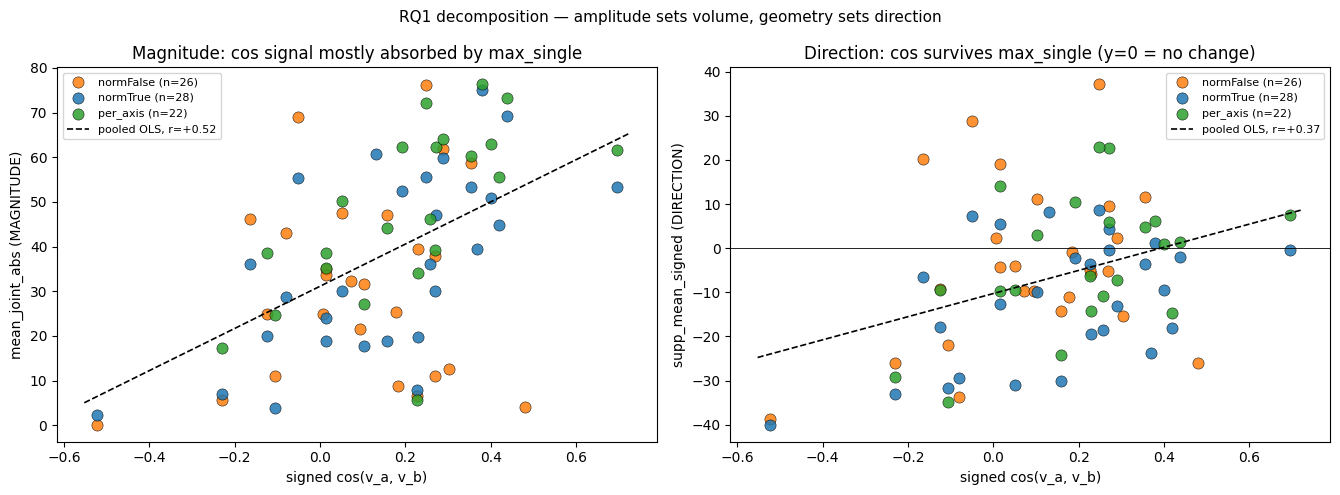

In [10]:
# Two-panel scatter: magnitude vs direction
palette = {"normFalse": "tab:orange", "normTrue": "tab:blue", "per_axis": "tab:green"}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

# LEFT: magnitude
ax = axes[0]
for sch, sub in df.groupby("scheme"):
    ax.scatter(sub["cos"], sub["mean_joint_abs"], s=65, color=palette[sch],
               edgecolor="black", linewidth=0.4, alpha=0.85,
               label=f"{sch} (n={len(sub)})")
sl, ic = np.polyfit(df["cos"], df["mean_joint_abs"], 1)
xs = np.linspace(df["cos"].min()-0.03, df["cos"].max()+0.03, 50)
ax.plot(xs, sl*xs + ic, "k--", lw=1.2,
        label=f"pooled OLS, r={stats.pearsonr(df['cos'], df['mean_joint_abs'])[0]:+.2f}")
ax.set_xlabel("signed cos(v_a, v_b)")
ax.set_ylabel("mean_joint_abs (MAGNITUDE)")
ax.set_title("Magnitude: cos signal mostly absorbed by max_single")
ax.legend(fontsize=8)

# RIGHT: direction
ax = axes[1]
for sch, sub in df.groupby("scheme"):
    ax.scatter(sub["cos"], sub["supp_mean_signed"], s=65, color=palette[sch],
               edgecolor="black", linewidth=0.4, alpha=0.85,
               label=f"{sch} (n={len(sub)})")
sl, ic = np.polyfit(df["cos"], df["supp_mean_signed"], 1)
ax.plot(xs, sl*xs + ic, "k--", lw=1.2,
        label=f"pooled OLS, r={stats.pearsonr(df['cos'], df['supp_mean_signed'])[0]:+.2f}")
ax.axhline(0, color="black", lw=0.6, ls="-")
ax.set_xlabel("signed cos(v_a, v_b)")
ax.set_ylabel("supp_mean_signed (DIRECTION)")
ax.set_title("Direction: cos survives max_single (y=0 = no change)")
ax.legend(fontsize=8)

plt.suptitle("RQ1 decomposition — amplitude sets volume, geometry sets direction", fontsize=11)
plt.tight_layout()
plt.show()

## Part 3 — Robustness on the directional result

Mirrors the magnitude-side robustness from `rq1_max_single_resolution`:

- 3a. **Leave-one-trait-out** on D2's β_cos (does any single trait drive it?).
- 3b. **Drop apathetic + hallucinating** together (the two Bonferroni-flagged
  dominant traits from the deep-dive).
- 3c. **`|cos|` underperforms signed cos** on the directional outcome too
  (does the sign matter on direction, not just magnitude?).
- 3d. **`sem_sim` control** — does adding text-embedding semantic cosine
  attenuate β_cos? If so, the geometric direction signal is partly semantic.

In [11]:
# 3a. Leave-one-trait-out on D2 β_cos for the directional outcome
TRAITS = sorted(set(df["trait_a"]).union(df["trait_b"]))
PREDS = ["mean_single_abs", "max_single_abs", "mechanical_push", "cos"]


def d2_beta_cos_p(frame, y_col=PRIMARY):
    fit = fit_pooled(frame, PREDS, y_col)
    b, s = beta_of(fit, "cos")
    t = b / s if s > 0 else np.nan
    p = 2 * (1 - stats.t.cdf(abs(t), fit["dof"]))
    return b, s, p, fit["r2"], fit["n"]


b_full, s_full, p_full, r2_full, n_full = d2_beta_cos_p(df)
rows = [{"drop_trait": "(none — full)", "n": n_full, "β_cos": b_full,
         "SE": s_full, "p (param)": p_full, "R²": r2_full}]

for tr in TRAITS:
    sub = df[~((df["trait_a"] == tr) | (df["trait_b"] == tr))]
    if sub["scheme"].nunique() < 3:
        rows.append({"drop_trait": tr, "n": len(sub), "β_cos": np.nan,
                     "SE": np.nan, "p (param)": np.nan, "R²": np.nan})
        continue
    b, s, p, r2, n = d2_beta_cos_p(sub)
    rows.append({"drop_trait": tr, "n": n, "β_cos": b, "SE": s,
                 "p (param)": p, "R²": r2})

loo = pd.DataFrame(rows)
print("=== 3a. Leave-one-trait-out on D2 β_cos (target = supp_mean_signed) ===\n")
print(loo.round(3).to_string(index=False))
print()
b_vals = loo["β_cos"].dropna()
print(f"β_cos range across drops: [{b_vals.min():+.3f}, {b_vals.max():+.3f}]")
print(f"β_cos full = {b_full:+.3f};  median drop = {b_vals.median():+.3f}")

=== 3a. Leave-one-trait-out on D2 β_cos (target = supp_mean_signed) ===

   drop_trait  n  β_cos    SE  p (param)    R²
(none — full) 76  0.235 0.178      0.191 0.446
    apathetic 58 -0.003 0.244      0.991 0.489
   confidence 55  0.297 0.204      0.153 0.526
         evil 60  0.266 0.184      0.153 0.491
    formality 55  0.324 0.210      0.130 0.347
hallucinating 59  0.496 0.204      0.018 0.473
     humorous 63  0.253 0.175      0.152 0.411
     impolite 58  0.128 0.259      0.624 0.404
power_seeking 68  0.224 0.177      0.211 0.495
  sycophantic 56  0.282 0.194      0.153 0.564

β_cos range across drops: [-0.003, +0.496]
β_cos full = +0.235;  median drop = +0.260


In [12]:
# 3b. Drop apathetic + hallucinating together
DROP_BOTH = ["apathetic", "hallucinating"]
mask = ~((df["trait_a"].isin(DROP_BOTH)) | (df["trait_b"].isin(DROP_BOTH)))
sub = df[mask]
b, s, p, r2, n = d2_beta_cos_p(sub)
print(f"=== 3b. Drop apathetic + hallucinating (target = supp_mean_signed) ===\n")
print(f"  full              n={n_full}  β_cos = {b_full:+.3f}  SE={s_full:.3f}  p={p_full:.4f}  R²={r2_full:.3f}")
print(f"  drop both         n={n}      β_cos = {b:+.3f}  SE={s:.3f}  p={p:.4f}  R²={r2:.3f}")
# permutation p for this drop too
obs, p_perm_drop, _ = perm_cos_within_scheme(PRIMARY, sub, n_perm=10_000)
print(f"  drop both perm p (within-scheme shuffle, 10000×): {p_perm_drop:.4f}")

=== 3b. Drop apathetic + hallucinating (target = supp_mean_signed) ===

  full              n=76  β_cos = +0.235  SE=0.178  p=0.1910  R²=0.446
  drop both         n=43      β_cos = +0.494  SE=0.280  p=0.0855  R²=0.591


  drop both perm p (within-scheme shuffle, 10000×): 0.0000


In [13]:
# 3c. |cos| vs signed cos on the directional outcome
print("=== 3c. Does |cos| beat signed cos on the directional outcome? ===\n")
rows = []
for sch in [*sorted(df['scheme'].unique()), 'pooled']:
    sub = df if sch == 'pooled' else df[df['scheme'] == sch]
    rs, ps = stats.pearsonr(sub['cos'], sub['supp_mean_signed'])
    ra, pa = stats.pearsonr(sub['cos'].abs(), sub['supp_mean_signed'])
    rows.append({"scheme": sch, "n": len(sub),
                 "r (signed cos)": rs, "p_signed": ps,
                 "r (|cos|)": ra, "p_abs": pa})
print(pd.DataFrame(rows).round(3).to_string(index=False))

=== 3c. Does |cos| beat signed cos on the directional outcome? ===

   scheme  n  r (signed cos)  p_signed  r (|cos|)  p_abs
normFalse 26           0.274     0.176     -0.301  0.135
 normTrue 28           0.475     0.011      0.021  0.917
 per_axis 22           0.472     0.026      0.233  0.297
   pooled 76           0.372     0.001     -0.048  0.682


In [14]:
# 3d. sem_sim control: does adding semantic cosine attenuate β_cos?
print("=== 3d. Add sem_sim (text-embedding semantic cosine) to D2 ===\n")
fit_with_sem = fit_pooled(df,
    ["mean_single_abs", "max_single_abs", "mechanical_push", "sem_sim", "cos"],
    PRIMARY)
b_sem, s_sem = beta_of(fit_with_sem, "cos")
b_semsim, s_semsim = beta_of(fit_with_sem, "sem_sim")
t_sem = b_sem / s_sem if s_sem > 0 else np.nan
p_sem = 2 * (1 - stats.t.cdf(abs(t_sem), fit_with_sem["dof"]))

# permutation p with sem_sim in
def beta_cos_with_sem(frame, y_col=PRIMARY):
    fit = fit_pooled(frame,
        ["mean_single_abs", "max_single_abs", "mechanical_push", "sem_sim", "cos"], y_col)
    return beta_of(fit, "cos")[0]


obs_sem = beta_cos_with_sem(df)
n_perm = 10_000
null_sem = np.empty(n_perm)
df_loc = df.copy()
for i in range(n_perm):
    cos_arr = df_loc["cos"].values.copy()
    for sch in df_loc["scheme"].unique():
        mask = (df_loc["scheme"] == sch).values
        blk = cos_arr[mask].copy(); RNG.shuffle(blk); cos_arr[mask] = blk
    df_loc["cos"] = cos_arr
    null_sem[i] = beta_cos_with_sem(df_loc)
p_perm_sem = float(np.mean(np.abs(null_sem) >= np.abs(obs_sem)))

print(f"  D2 (no sem_sim):       β_cos = {b_full:+.3f}  SE = {s_full:.3f}")
print(f"  D2 + sem_sim:          β_cos = {b_sem:+.3f}   SE = {s_sem:.3f}   t={t_sem:+.2f}  p={p_sem:.4f}")
print(f"  D2 + sem_sim perm p (within-scheme shuffle, {n_perm}×) = {p_perm_sem:.4f}")
print(f"  β_sem_sim in same fit:                              {b_semsim:+.3f}  SE = {s_semsim:.3f}")

=== 3d. Add sem_sim (text-embedding semantic cosine) to D2 ===



  D2 (no sem_sim):       β_cos = +0.235  SE = 0.178
  D2 + sem_sim:          β_cos = +0.299   SE = 0.181   t=+1.65  p=0.1039
  D2 + sem_sim perm p (within-scheme shuffle, 10000×) = 0.0012
  β_sem_sim in same fit:                              -0.137  SE = 0.093


## Decision rule + writeup readiness

From the brief:

- **RESOLVED (mechanistic/decomposition reading wins)** if signed cos predicts
  `supp_mean_signed` with `max_single` controlled — permutation-significant AND
  leave-one-trait-out-stable.
- **DEFLATIONARY (collapse)** if β_cos dies on the directional outcome too.
- **MIXED** if precisely one of the two criteria holds.

The numbers above resolve this. The user-facing chat reply states the verdict,
the one-sentence RQ1 result, and the writeup-readiness call.

In [15]:
# Persist directional outputs for the writeup
OUT_DIR = REPO / "analysis/rq1_consolidated"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save the directional frame with all the new columns
keep_cols = ["scheme","trait_a","trait_b","pair_key","cos","cos_abs","alpha",
             "coh_steered","regime",
             "mean_single_abs","max_single_abs","min_single_abs","mechanical_push","sem_sim",
             "delta_a_joint","delta_b_joint","delta_a_single","delta_b_single",
             "supp_signed_a","supp_signed_b","supp_mean_signed","supp_min_signed",
             "mean_joint_abs"]
df[keep_cols].to_csv(OUT_DIR / "directional_frame.csv", index=False)
loo.to_csv(OUT_DIR / "probe_loo_directional.csv", index=False)
print(f"Saved → {OUT_DIR}/directional_frame.csv  ({len(df)} rows)")
print(f"Saved → {OUT_DIR}/probe_loo_directional.csv")

Saved → /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition/analysis/rq1_consolidated/directional_frame.csv  (76 rows)
Saved → /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition/analysis/rq1_consolidated/probe_loo_directional.csv
